# Bevezetés a hálózattudományba (Network Science)

A **hálózattudomány** (Network Science) a **kapcsolatok és kölcsönhatások rendszerszintű vizsgálatával** foglalkozik.  
A cél, hogy megértsük, **hogyan kapcsolódnak az egyes elemek**, és **milyen szerepet** töltenek be az egész hálózat működésében.



## Alapfogalmak

- **Csomópont (Node):** egy egyed vagy entitás (pl. ember, weboldal, fehérje).  
- **Él (Edge):** kapcsolat a csomópontok között (pl. barátság, kommunikáció, link).  
- **Súly (Weight):** a kapcsolat erőssége vagy gyakorisága.  
- **Irányítottság:** az él mutathat irányt (pl. követés a Twitteren, hivatkozás az interneten).



## Példák hálózatokra

| Típus | Csomópont | Él |
|:------|:-----------|:---|
| Társadalmi hálózat | Ember | Barátság, kapcsolat |
| Internet | Weboldal | Hiperhivatkozás |
| Biológiai hálózat | Fehérje, gén | Interakció |
| Infrastruktúra | Város | Útvonal, energiaáramlás |



## Miért fontos a hálózatelemzés?

- Segít megérteni a **kapcsolati mintázatokat** és **információáramlást**.  
- Felfedi a **kulcsszereplőket** (influenszerek, hubok).  
- Képes kimutatni **közösségeket** és **struktúrákat** a rendszerben.  
- Alkalmazható a **biológiától** a **közgazdaságtanon** át a **szociológiáig**.



##  Mit fogunk látni ebben a jegyzetben?

1. A hálózatok vizualizálása és alapjellemzők megismerése  
2. A legfontosabb **centralitás-mutatók** (degree, betweenness, closeness, eigenvector)
3. **Közösségek felismerése** (community detection)  
4. **Zachary’s Karate Club** hálózat elemzése – egy klasszikus szociális példán keresztül


> *A hálózattudomány a modern adatvilág „láthatatlan térképe” – megmutatja, ki, mivel, hogyan és mennyire van összekapcsolva.*


## Egyszerű kézi hálózat létrehozása

A hálózatokat nemcsak adatfájlból tölthetjük be, hanem **kézzel is létrehozhatjuk**.

Ebben a példában egy **kis társadalmi hálózatot** építünk fel:  
4 ember barátságait modellezzük egy irányítatlan gráfban.

Csomópontok (emberek):  
- Anna  
- Béla  
- Csilla  
- Dávid  

Élek (barátságok):  
- Anna – Béla  
- Anna – Csilla  
- Béla – Dávid  
- Csilla – Dávid  

Ez egy kis, zárt hálózat, amelyen könnyen szemléltethető a **kapcsolatok szerkezete**.


In [1]:
# Könyvtár importálása
import networkx as nx
import matplotlib.pyplot as plt

# Üres gráf létrehozása
G_manual = nx.Graph()

In [2]:
# Csomópontok hozzáadása
G_manual.add_nodes_from(["Anna", "Béla", "Csilla", "Dávid"])

# Élek (kapcsolatok) hozzáadása
G_manual.add_edges_from([
    ("Anna", "Béla"),
    ("Anna", "Csilla"),
    ("Béla", "Dávid"),
    ("Csilla", "Dávid")
])

In [3]:
# Gráf alapinformációk
print("Csomópontok:", G_manual.nodes())
print("Élek:", G_manual.edges())

Csomópontok: ['Anna', 'Béla', 'Csilla', 'Dávid']
Élek: [('Anna', 'Béla'), ('Anna', 'Csilla'), ('Béla', 'Dávid'), ('Csilla', 'Dávid')]


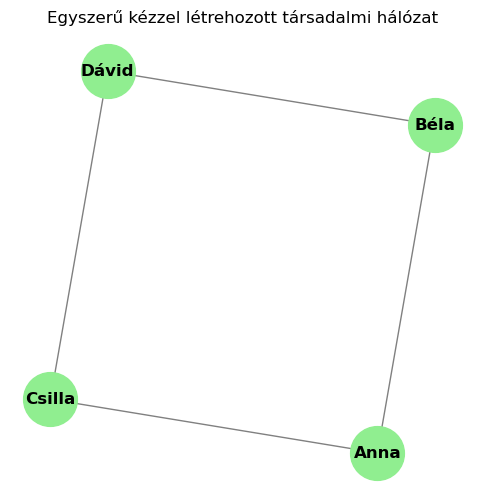

In [4]:
# Vizualizáció
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G_manual, seed=42)  # rendezett elhelyezés
nx.draw_networkx(
    G_manual,
    pos,
    with_labels=True,
    node_color='lightgreen',
    edge_color='gray',
    node_size=1500,
    font_size=12,
    font_weight='bold'
)
plt.title("Egyszerű kézzel létrehozott társadalmi hálózat")
plt.axis('off')
plt.show()

### Értelmezés

- A **csomópontok** az embereket jelképezik.  
- A **vonalak (élek)** a köztük lévő barátságokat mutatják.  
- Látható, hogy Anna mindkét oldalon kapcsolatban áll (központibb szerep).  
- Béla és Csilla nem ismerik közvetlenül egymást, de Dávidon keresztül kapcsolódnak.  

Ez az apró példahálózat segít megérteni, hogyan épülnek fel a **nagyobb és bonyolultabb hálózatok**.


## Kicsit összetettebb barátsági hálózat és alapvető gráfmetrikák

Ebben a példában 7 emberből álló kis társadalmi hálózatot hozunk létre, amelyben a barátságokat irányítatlan élek jelképezik.

**Cél:**  
- Megvizsgálni, kik a legnépszerűbb (legtöbb kapcsolattal rendelkező) személyek.  
- Azonosítani a kapcsolatokat „összekötő hidakat”.  
- Kiszámolni a legfontosabb **centralitás-mutatókat**.



### A hálózat felépítése

Csomópontok:  
`["Anna", "Béla", "Csilla", "Dávid", "Erika", "Ferenc", "Gabi"]`

Barátságok (élek):  
- Anna – Béla  
- Anna – Csilla  
- Béla – Dávid  
- Csilla – Dávid  
- Dávid – Erika  
- Erika – Ferenc  
- Ferenc – Gabi  
- Csilla – Gabi  
- Béla – Erika


In [5]:
# Gráf létrehozása
G = nx.Graph()

In [6]:
# Csomópontok és élek
G.add_nodes_from(["Anna", "Béla", "Csilla", "Dávid", "Erika", "Ferenc", "Gabi"])
G.add_edges_from([
    ("Anna", "Béla"),
    ("Anna", "Csilla"),
    ("Béla", "Dávid"),
    ("Csilla", "Dávid"),
    ("Dávid", "Erika"),
    ("Erika", "Ferenc"),
    ("Ferenc", "Gabi"),
    ("Csilla", "Gabi"),
    ("Béla", "Erika")
])

In [7]:
# Alapinformációk
print(f"Csomópontok száma: {G.number_of_nodes()}")
print(f"Élek száma: {G.number_of_edges()}")

Csomópontok száma: 7
Élek száma: 9


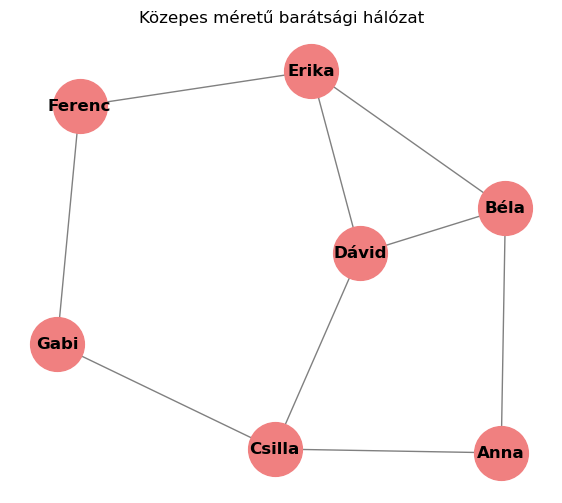

In [8]:
# Vizualizáció
plt.figure(figsize=(7,6))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(
    G, pos,
    with_labels=True,
    node_color='lightcoral',
    node_size=1500,
    font_weight='bold',
    edge_color='gray'
)
plt.title("Közepes méretű barátsági hálózat")
plt.axis('off')
plt.show()

### Alapvető gráfmetrikák

A hálózatban különböző „centralitás” mutatók segítségével mérhetjük,  
mely csomópontok a legfontosabbak a kapcsolatrendszer szempontjából.

| Mutató | Jelentés |
|:--|:--|
| **Degree centrality** | Hány közvetlen kapcsolata van az adott csomópontnak |
| **Betweenness centrality** | Milyen gyakran helyezkedik el a legrövidebb utak középpontjában (híd-szerep) |
| **Closeness centrality** | Átlagosan milyen közel van az összes többi csomóponthoz |
| **Eigenvector centrality** | Mennyire „befolyásos”, figyelembe véve a kapcsolatai befolyását is |


In [9]:
import pandas as pd
# Centralitásmutatók kiszámítása
degree = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
eigenvector = nx.eigenvector_centrality(G)

# Eredmények összefoglalása táblázatban
metrics = pd.DataFrame({
    "Degree": degree,
    "Betweenness": betweenness,
    "Closeness": closeness,
    "Eigenvector": eigenvector
}).round(3)

metrics.sort_values("Degree", ascending=False)


,Degree,Betweenness,Closeness,Eigenvector
Béla,0.500,0.133,0.600,0.459
Csilla,0.500,0.244,0.667,0.382
Dávid,0.500,0.122,0.667,0.478
Erika,0.500,0.189,0.667,0.443
Anna,0.333,0.056,0.545,0.313
Ferenc,0.333,0.089,0.545,0.253
Gabi,0.333,0.100,0.545,0.236


### Centralitás-értékek értelmezése

A fenti táblázatban látható a hét szereplő alapvető hálózati metrikája.  
A számok 0 és 1 között mozognak, ahol a nagyobb érték **fontosabb vagy központibb szerepet** jelez.

| Mutató | Jelentés | Értelmezés a hálózatban |
|:--|:--|:--|
| **Degree** | Hány közvetlen kapcsolat | Béla, Csilla, Dávid és Erika a legjobban kapcsolódó személyek. |
| **Betweenness** | Híd-szerep – hány út halad át rajta | Csilla és Erika fontos „összekötők” a hálózat két fele között. |
| **Closeness** | Átlagos távolság a többiektől | Dávid, Csilla és Erika gyorsan elérhetik az összes többit → központi pozíció. |
| **Eigenvector** | Befolyás – fontos kapcsolatok fontossága | Dávid és Béla erősen kapcsolódnak más fontos tagokhoz. |

**Összefoglalva:**
- **Dávid** a legkiegyensúlyozottabban központi tag (magas minden mutatóban).  
- **Csilla** a legfontosabb híd (magas betweenness).  
- **Erika** kulcsszereplő a két rész közti információáramlásban.  
- **Anna**, **Ferenc** és **Gabi** inkább periférián helyezkednek el.


> Ezek a mutatók együtt adják meg a hálózat „térképét”:  
> ki a népszerű, ki az összekötő, és ki van a periférián.


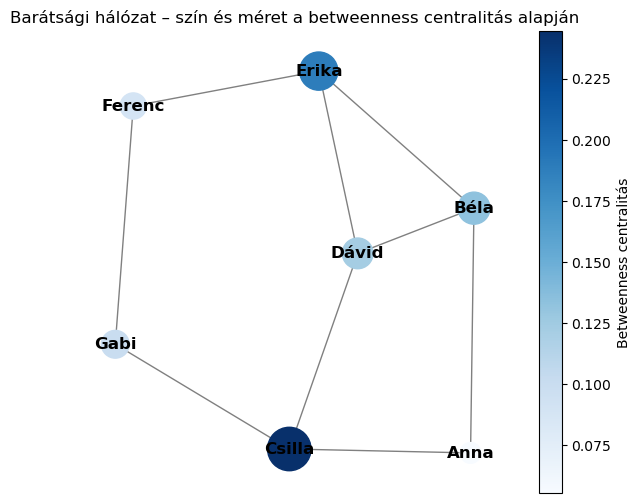

In [10]:
# Betweenness centralitás szerinti színezett vizualizáció

plt.figure(figsize=(7,6))
pos = nx.spring_layout(G, seed=42)

# Betweenness centralitás értékek kinyerése
betweenness_values = nx.betweenness_centrality(G)

# Node színek – a centralitás alapján (világos → sötétkék)
node_colors = [betweenness_values[n] for n in G.nodes()]

# Rajzolás szín- és méretkódolással
nodes = nx.draw_networkx_nodes(
    G, pos,
    node_size=[4000 * betweenness_values[n] for n in G.nodes()],
    node_color=node_colors,
    cmap=plt.cm.Blues
)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1)
nx.draw_networkx_labels(G, pos, font_weight='bold')

# Színskála (colorbar)
plt.colorbar(nodes, label="Betweenness centralitás")

plt.title("Barátsági hálózat – szín és méret a betweenness centralitás alapján")
plt.axis('off')
plt.show()


### Értelmezés

- **Degree centrality:** Béla, Csilla és Dávid a legjobban kapcsolódó tagok → ők a „népszerűek”.  
- **Betweenness centrality:** Erika és Dávid gyakran szerepelnek a legrövidebb utak köztes pontjaként → ők „hidat” képeznek a csoportok között.  
- **Closeness centrality:** Azok a csomópontok, amelyek gyorsan elérhetik az összes többit (pl. Dávid).  
- **Eigenvector centrality:** Megmutatja, ki van kapcsolatban más fontos emberekkel → a „befolyásos barátok barátai”.  

Ez a kis példahálózat már jól szemlélteti, hogyan tudjuk **mérni a szereplők fontosságát** a kapcsolatrendszerben.


### A hálózat bővítése

Kibővítjük a barátsági hálózatot 11 szereplőre, hogy már valódi alcsoportok alakulhassanak ki:
-  például egy „A” csoport (Anna, Béla, Csilla, Dávid, Erika)
-  és egy „B” csoport (Ferenc, Gabi, Hajni, Imre, Jani, Kati).
  
Közöttük néhány „híd” kapcsolat lesz.

In [11]:
# Új, nagyobb hálózat
G2 = nx.Graph()

In [12]:
# Csomópontok (11 fő)
nodes = ["Anna", "Béla", "Csilla", "Dávid", "Erika",
         "Ferenc", "Gabi", "Hajni", "Imre", "Jani", "Kati"]
G2.add_nodes_from(nodes)

In [13]:
# Élek – két csoport, kevés átkötéssel
edges = [
    # 1. közösség
    ("Anna", "Béla"), ("Anna", "Csilla"), ("Béla", "Dávid"), ("Csilla", "Dávid"),
    ("Dávid", "Erika"), ("Erika", "Béla"), ("Anna", "Erika"),
    
    # 2. közösség
    ("Ferenc", "Gabi"), ("Ferenc", "Hajni"), ("Gabi", "Imre"),
    ("Imre", "Jani"), ("Jani", "Kati"), ("Hajni", "Kati"),
    
    # Kapcsolatok a két közösség között
    ("Csilla", "Ferenc"), ("Erika", "Imre")
]

In [14]:
G2.add_edges_from(edges)

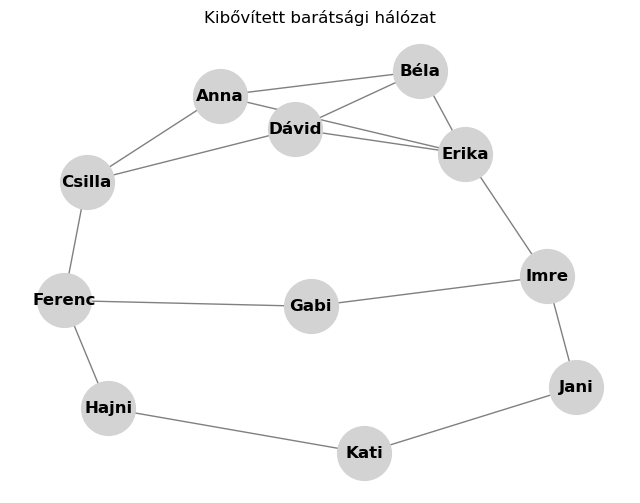

In [15]:
# Vizualizáció
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G2, seed=42)
nx.draw_networkx(
    G2, pos,
    with_labels=True,
    node_color='lightgray',
    edge_color='gray',
    node_size=1500,
    font_weight='bold'
)
plt.title("Kibővített barátsági hálózat")
plt.axis('off')
plt.show()

## Közösségdetektálás – Girvan–Newman algoritmus

A Girvan–Newman módszer iteratívan eltávolítja a legnagyobb betweenness centrality-vel rendelkező éleket,
amíg a hálózat jól elkülönülő klaszterekre esik szét.

In [16]:
from networkx.algorithms.community import girvan_newman

# 1. Közösségek meghatározása
communities = next(girvan_newman(G2))

# 2. Közösségek listája
communities = [list(c) for c in communities]
for i, c in enumerate(communities):
    print(f"Közösség {i+1}: {c}")


Közösség 1: ['Béla', 'Erika', 'Anna', 'Csilla', 'Dávid']
Közösség 2: ['Ferenc', 'Hajni', 'Kati', 'Jani', 'Imre', 'Gabi']


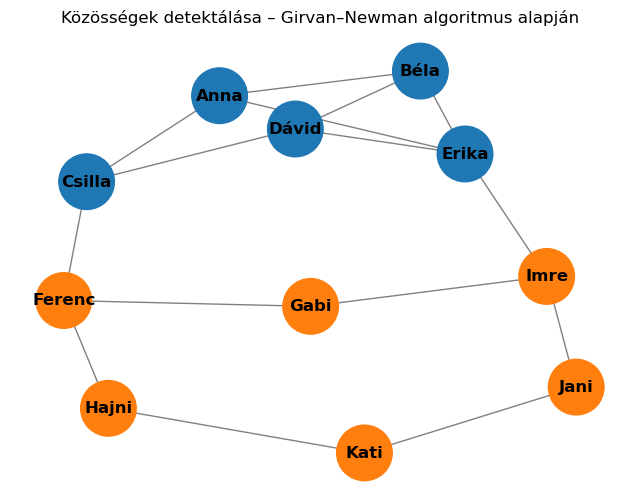

In [17]:
import matplotlib.colors as mcolors

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G2, seed=42)

# Színek közösségenként
colors = list(mcolors.TABLEAU_COLORS.keys())
node_colors = []
for n in G2.nodes():
    for i, c in enumerate(communities):
        if n in c:
            node_colors.append(colors[i % len(colors)])

nx.draw_networkx(
    G2, pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=1600,
    font_weight='bold'
)
plt.title("Közösségek detektálása – Girvan–Newman algoritmus alapján")
plt.axis('off')
plt.show()


### Mit látunk?

- A hálózat két jól elkülönülő **közösséget** tartalmaz:
  - Az egyik csoport: Anna, Béla, Csilla, Dávid, Erika  
  - A másik: Ferenc, Gabi, Hajni, Imre, Jani, Kati
- A két csoportot **Csilla–Ferenc** és **Erika–Imre** kapcsolatai kötik össze → ezek a **„híd-élek”**.
- Ez a szerkezet tipikus példája egy **moduláris hálózatnak**, ahol sűrűn összekapcsolt csoportok gyengén kapcsolódnak egymáshoz.


## Közösségek kiértékelése – modularitás és statisztikák

A közösségdetektálás eredményét nemcsak vizuálisan, hanem **számszerűen** is értékelhetjük.

A legfontosabb mérőszám a **modularity**:

> **Modularitás (Q):**  
> azt méri, hogy az azonos közösségbe tartozó csomópontok mennyivel sűrűbben kapcsolódnak egymáshoz,  
> mint amennyi véletlenül várható lenne.

- Értéke **–1 és +1 között** van.  
- **0.3 felett** már jól elkülönülő közösségek.  
- **0.5–0.7** → erősen moduláris szerkezet.


In [18]:
from networkx.algorithms.community import modularity

# Modularitás számítása
Q = modularity(G2, communities)
print(f"Modularitás értéke: {Q:.3f}")

# Közösségek mérete
sizes = [len(c) for c in communities]
for i, s in enumerate(sizes, 1):
    print(f"Közösség {i} mérete: {s} csomópont")

# Alap statisztikák táblázatban
import pandas as pd

community_summary = pd.DataFrame({
    "Közösség": [f"{i+1}" for i in range(len(communities))],
    "Méret (csomópont)": sizes
})
community_summary["Tagok"] = [", ".join(sorted(c)) for c in communities]
display(community_summary)


Modularitás értéke: 0.364
Közösség 1 mérete: 5 csomópont
Közösség 2 mérete: 6 csomópont


,Közösség,Méret (csomópont),Tagok
0,1,5,"Anna, Béla, Csilla, Dávid, Erika"
1,2,6,"Ferenc, Gabi, Hajni, Imre, Jani, Kati"


## Legbefolyásosabb személyek listája centralitás alapján

A hálózatban a befolyás mértéke többféleképp definiálható.  
A leggyakrabban használt mérőszámok:

| Mutató | Mit mér? | Mit jelent a hálózatban? |
|:--|:--|:--|
| **Degree centrality** | Kapcsolatok száma | „Népszerűség” |
| **Betweenness centrality** | Hány legrövidebb út halad át rajta | „Híd-szerep” |
| **Eigenvector centrality** | Kapcsolatok fontossága | „Befolyás” |
| **Closeness centrality** | Átlagos távolság a többiektől | „Elérhetőség” |

A valódi „befolyásos személy” az, aki **több mutatóban is magas értéket ér el**.


In [19]:
# Centralitások kiszámítása
degree = nx.degree_centrality(G2)
betweenness = nx.betweenness_centrality(G2)
closeness = nx.closeness_centrality(G2)
eigen = nx.eigenvector_centrality(G2)

In [20]:
# Táblázat létrehozása
df_centrality = pd.DataFrame({
    "Degree": degree,
    "Betweenness": betweenness,
    "Closeness": closeness,
    "Eigenvector": eigen
}).round(3)

In [21]:
# Átlagolt befolyás-score (egyszerű összesítés)
df_centrality["Influence_Score"] = df_centrality.mean(axis=1).round(3)

In [22]:
# Top lista
df_ranked = df_centrality.sort_values("Influence_Score", ascending=False)
display(df_ranked)

,Degree,Betweenness,Closeness,Eigenvector,Influence_Score
Erika,0.4,0.256,0.500,0.491,0.412
Imre,0.3,0.302,0.526,0.238,0.342
Csilla,0.3,0.211,0.476,0.329,0.329
Ferenc,0.3,0.257,0.500,0.179,0.309
Anna,0.3,0.070,0.455,0.411,0.309
Dávid,0.3,0.070,0.455,0.411,0.309
Béla,0.3,0.007,0.417,0.432,0.289
Gabi,0.2,0.070,0.455,0.137,0.216
Jani,0.2,0.117,0.417,0.097,0.208
Hajni,0.2,0.094,0.400,0.078,0.193


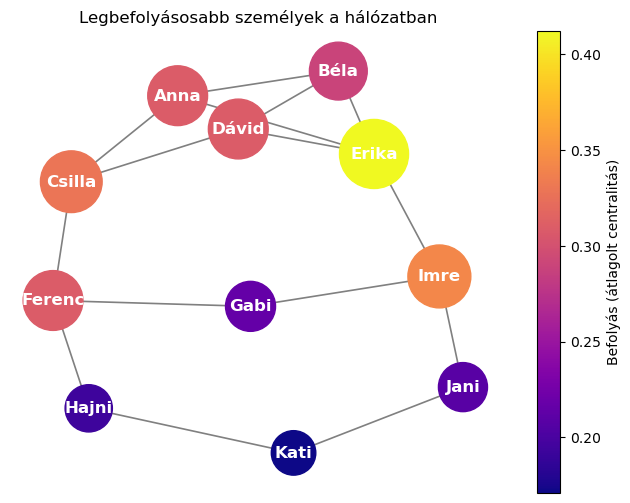

In [23]:
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G2, seed=42)

# Színek és méretek az influence score alapján
influence = df_centrality["Influence_Score"]
node_colors = [influence[n] for n in G2.nodes()]
node_sizes = [6000 * influence[n] for n in G2.nodes()]

nodes = nx.draw_networkx_nodes(
    G2, pos,
    node_color=node_colors,
    node_size=node_sizes,
    cmap=plt.cm.plasma
)
nx.draw_networkx_edges(G2, pos, edge_color="gray", width=1.2)
nx.draw_networkx_labels(G2, pos, font_weight="bold", font_color="white")

plt.colorbar(nodes, label="Befolyás (átlagolt centralitás)")
plt.title("Legbefolyásosabb személyek a hálózatban")
plt.axis('off')
plt.show()


In [24]:
community_influencers = []

for i, comm in enumerate(communities, start=1):
    sub = df_centrality.loc[comm].sort_values("Influence_Score", ascending=False)
    top_name = sub.index[0]
    top_score = sub["Influence_Score"].iloc[0]
    community_influencers.append((i, top_name, top_score))

df_influencers = pd.DataFrame(community_influencers, columns=["Közösség", "Legbefolyásosabb tag", "Influence_Score"])
display(df_influencers)


,Közösség,Legbefolyásosabb tag,Influence_Score
0,1,Erika,0.412
1,2,Imre,0.342


### Összegzés

- A hálózat legbefolyásosabb tagjai azok, akik **magas centralitási értékekkel** bírnak több dimenzióban is.  
- A közösségenkénti listák segítenek azonosítani a **lokális vezetőket** –  
  akik nem az egész hálózatban dominánsak, hanem a saját csoportjukban kulcsszereplők.

> Ez a megközelítés gyakori a szociális hálózatelemzésben, vállalati struktúrákban vagy  
> akár fertőzésmodellezésben is – a központi szereplők terjesztik leggyorsabban az információt (vagy a vírust).


## Filmek közötti hasonlósági hálózat

**Cél:**
Megmutatni, hogy a filmek közötti közös nézők alapján
gráfot építünk, és az így kapott hálózatban:

- klaszterek → filmközösségek (pl. akció, romantikus)
- centralitás → kulcsfilmek (mindenki látta: Star Wars, Matrix stb.)
- közösségdetektálás → ízek szerint csoportosuló nézők / műfajok

## Minimális demóötlet (NetworkX-szel)

In [25]:
#  MovieLens 100k letöltése
url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
df = pd.read_csv(url, sep="\t", names=["user", "movie", "rating", "timestamp"])


In [40]:
# Top 20 legnézettebb film kiválasztása
top_movies = df["movie"].value_counts().head(20).index
df_top = df[df["movie"].isin(top_movies)]

# Csak azok a felhasználók, akik ezek közül legalább 20 értékeltek
user_counts = df_top["user"].value_counts()
active_users = user_counts[user_counts >= 15].index
df_top = df_top[df_top["user"].isin(active_users)]

print(f"Adatok: {df_top['user'].nunique()} user × {df_top['movie'].nunique()} film")

Adatok: 172 user × 20 film


In [41]:
# Felhasználók és filmek közötti élek (bipartit hálózat)
G = nx.Graph()
G.add_nodes_from(df_top["user"].unique(), bipartite="users")
G.add_nodes_from(df_top["movie"].unique(), bipartite="movies")
G.add_edges_from(list(zip(df_top["user"], df_top["movie"])))

In [62]:
df_top["movie"].nunique()

20

In [42]:
# Film-film hálózat létrehozása közös nézők alapján
movie_graph = nx.projected_graph(G, df_top["movie"].unique())

In [43]:
# Közösségek detektálása
from networkx.algorithms.community import girvan_newman
communities = next(girvan_newman(movie_graph))

In [44]:
# Központi filmek megkeresése
centrality = nx.degree_centrality(movie_graph)
top_movies = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 központi film:", top_movies)

Top 10 központi film: [(np.int64(222), 1.0), (np.int64(1), 1.0), (np.int64(98), 1.0), (np.int64(117), 1.0), (np.int64(294), 1.0), (np.int64(258), 1.0), (np.int64(172), 1.0), (np.int64(181), 1.0), (np.int64(7), 1.0), (np.int64(237), 1.0)]


In [61]:
print("Csomópontok:", movie_graph.number_of_nodes())
print("Élek:", movie_graph.number_of_edges())


Csomópontok: 186
Élek: 3510


## Mit ad ez, amit a klaszterezés nem?

A kapcsolat maga a jelentés → közös nézők, nem puszta hasonlóság.

Tudsz vizsgálni:
- közösségeket (pl. műfaj-alapú filmklaszterek),
- befolyásos filmeket (hubok),
- információterjedést („ha tetszett ez, valószínű ezt is láttad”).

A gráfban a kontekstus is látszik: ki mihez kapcsolódik → ami egy OHE-mátrixból elveszik.

In [68]:
# Filmcímek betöltése
url_movies = "https://files.grouplens.org/datasets/movielens/ml-100k/u.item"
cols = ["movie_id", "title", "release_date", "video_release_date", "IMDb_URL",
        "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy", "Crime",
        "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
        "Romance", "Sci-Fi", "Thriller", "War", "Western"]
movies = pd.read_csv(url_movies, sep="|", names=cols, encoding="latin-1")
id_to_title = dict(zip(movies["movie_id"], movies["title"]))

In [69]:
# Csak a top 10 film és szomszédaik alhálózata
top_10 = [int(m) for m, _ in top_movies]
sub_nodes = set(top_10)
for n in top_10:
    sub_nodes.update(movie_graph.neighbors(n))
subG = movie_graph.subgraph(sub_nodes)

In [70]:
# Interaktív hálózat létrehozása PyVis-szel
net = Network(height="750px", width="100%", bgcolor="#ffffff", font_color="black")

for node in subG.nodes():
    title = id_to_title.get(node, str(node))
    color = "red" if node in top_10 else "#a0c4ff"
    size = 25 if node in top_10 else 10
    label = title[:35] if node in top_10 else ""  # csak top filmek címkézése
    net.add_node(str(node), label=label, title=title, color=color, size=size)

for source, target in subG.edges():
    net.add_edge(str(source), str(target), color="#cccccc")


In [72]:
net.toggle_physics(False)


In [73]:
# HTML fájl létrehozása és automatikus megnyitása
net.write_html("movielens_top_films.html")
webbrowser.open("movielens_top_films.html")

True